Custom Result: y = 3.9398x + 1.7202
Numpy Result:  y = 3.9398x + 1.7202
Smallest residual: 0.001972766896133571 at point 0.81
Largest residual: 1.0228607556966165 at point 0.72


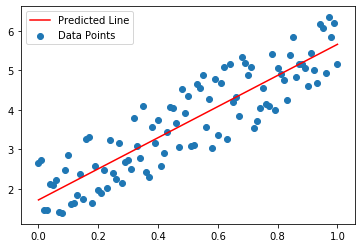

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def manual_least_squares(X, Y):
    # Implement own Least Squares Method using matrix operations
    A = np.vstack([X, np.ones(len(X))]).T
    beta = np.linalg.inv(A.T @ A) @ (A.T @ Y)
    return beta

# Choose a random linear function with a random error (0 to 1)
m, b = 3.5, 2.0
# Create data points: X: 0 to 1, steps of .01
X = np.arange(0, 1.01, 0.01)
# +/- random_number(0, 1)
noise = np.random.uniform(-1, 1, len(X))
Y = m * X + b + noise

# Sort the X vector
idx = np.argsort(X)
X = X[idx]
Y = Y[idx]

# Compare custom method with built-in Numpy function
m_custom, b_custom = manual_least_squares(X, Y)
A_np = np.vstack([X, np.ones(len(X))]).T
m_numpy, b_numpy = np.linalg.lstsq(A_np, Y, rcond=None)[0]

# Print results
print(f"Custom Result: y = {m_custom:.4f}x + {b_custom:.4f}")
print(f"Numpy Result:  y = {m_numpy:.4f}x + {b_numpy:.4f}")

# Print out the residuals and identify largest/smallest errors
Y_pred = m_custom * X + b_custom
residuals = np.abs(Y - Y_pred)
max_err_idx = np.argmax(residuals)
min_err_idx = np.argmin(residuals)

print(f"Smallest residual: {residuals[min_err_idx]} at point {X[min_err_idx]}")
print(f"Largest residual: {residuals[max_err_idx]} at point {X[max_err_idx]}")

# Plot the points and the predicted line
plt.scatter(X, Y, label='Data Points')
plt.plot(X, Y_pred, color='red', label='Predicted Line')
plt.legend()
plt.show()